# Results summary: BPTT vs PC, two-prior RSG (10-seed cluster sweep)

**Purpose:** hand-off summary for the team. This notebook only *reads* saved metrics
(`results/runs/*/seed_*/metrics.json`, via `scripts/summarize_runs.py`) and already-generated
figures (`scripts/plot_pc_activity.py`) — it does not retrain or recompute anything, per
`AGENTS.md` ("Plotting reads saved metrics ... never retrains").

**Three conditions**, all `reduced` regime (`dt=5`, `N=160`), `n_iter=3000`, real cluster runs
(jobs 317/327/347/349 on `sld.umd.edu`):

| variant | rule | `pc_inference_steps` | seeds complete |
|---|---|---|---|
| `bptt` | BPTT | n/a | 10/10 |
| `pc_steps20` | PC | 20 (default) | 10/10 |
| `pc_steps100` | PC | 100 | 9/10 (seed 1 stopped at iter 2800/3000, wall-time limit — not resubmitted, excluded from behavior stats below) |

**Known data gap:** `pc_steps20`'s saved activation arrays (used for PCA/unit-activity/output-vs-target
plots, *not* the metrics/behavior numbers) collided on the cluster with `pc_steps100`'s activation
writes (both runs share the rule name `pc` and `pc_steps100` didn't have a separate `ACTIVATION_STORE`
at submission time). 6 of 10 `pc_steps20` seeds lost their activations permanently; metrics/behavior are
unaffected for all 10. See `has_activations` in the table below.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
df = pd.read_csv(REPO_ROOT / "results" / "runs_summary.csv")
df

,variant,rule,seed,complete,has_activations,best_loss,final_loss,n_iter_run,valid_tp_count,valid_tp_total,slope_short,slope_long
0,bptt,bptt,0,True,True,0.045501,0.129417,3000,0.0,20.0,NaN,NaN
1,bptt,bptt,1,True,True,0.043885,0.164219,3000,5.0,20.0,4.604794e-04,NaN
2,bptt,bptt,2,True,True,0.049972,0.300455,3000,0.0,20.0,NaN,NaN
3,bptt,bptt,3,True,True,0.015400,0.151933,3000,15.0,20.0,4.691929e-01,7.445434e-02
4,bptt,bptt,4,True,True,0.017672,0.025631,3000,20.0,20.0,-2.761231e-04,-4.482047e-05
5,bptt,bptt,5,True,True,0.003019,0.008125,3000,20.0,20.0,6.947057e-01,8.066678e-01
6,bptt,bptt,6,True,True,0.032699,0.175320,3000,10.0,20.0,1.835427e-02,1.066673e-03
7,bptt,bptt,7,True,True,0.028335,0.178592,3000,15.0,20.0,1.546309e-02,4.423301e-03
8,bptt,bptt,8,True,True,0.002373,0.005365,3000,20.0,20.0,7.882605e-01,7.635866e-01
9,bptt,bptt,9,True,True,0.039147,0.176443,3000,15.0,20.0,4.028055e-02,-3.771119e-03


## Per-variant summary (mean ± std over seeds)

Per `AGENTS.md` ("Seeds are the unit of evidence ... never report a single network per condition"),
always read this alongside the full per-seed table above, not instead of it.

In [2]:
complete = df[df["complete"]]
summary = complete.groupby("variant").agg(
    n_seeds=("seed", "count"),
    best_loss_mean=("best_loss", "mean"),
    best_loss_std=("best_loss", "std"),
    valid_tp_mean=("valid_tp_count", "mean"),
    valid_tp_std=("valid_tp_count", "std"),
    slope_short_mean=("slope_short", "mean"),
    slope_short_std=("slope_short", "std"),
    slope_long_mean=("slope_long", "mean"),
    slope_long_std=("slope_long", "std"),
).round(4)
summary

,n_seeds,best_loss_mean,best_loss_std,valid_tp_mean,valid_tp_std,slope_short_mean,slope_short_std,slope_long_mean,slope_long_std
variant,,,,,,,,,
bptt,10,0.0278,0.0174,12.0000,7.8881,0.2533,0.3408,0.2352,0.3769
pc_steps100,9,0.0076,0.0123,6.6667,8.2916,-0.2176,0.4746,0.0000,0.0000
pc_steps20,10,0.0287,0.0127,0.0000,0.0000,NaN,NaN,NaN,NaN


## Key finding

- **BPTT** is genuinely seed-dependent: 2/10 seeds produce zero valid responses, 3/10 (seeds 3, 5, 8;
  also 6 is close) give clean positive slopes in the theoretically-expected Bayesian-bias range (long
  prior flatter than short), the rest partial. A real, honest spread — not a clean story.
- **PC at the default `pc_inference_steps=20`** collapses uniformly: **0/10 seeds** produce a single
  valid threshold crossing, despite loss converging in the same range as BPTT. The failure is the
  behavioral readout (flat, `ts`-independent output per prior×effector group), not a training failure.
- **PC at `pc_inference_steps=100`** breaks the uniform collapse — 4 of 9 seeds now show partial-to-full
  threshold crossings (seed 3, 4: 20/20; seed 0, 2: 5/20; seed 8: 10/20), and loss converges far lower
  (~1e-4 vs ~1e-2 for steps=20). **But the slopes are near-zero or negative**, not the positive
  Bayesian-bias slopes BPTT shows — i.e. steps=100 fixes threshold-crossing but not yet genuine
  interval-dependent, prior-modulated timing. Seed 2's slope (−1.07) is a clear outlier, worth a second
  look at that seed's raw output before treating it as representative.

Full technical trail (every hypothesis tested, exact numbers): `.suplex/docs/discrepancy_log.md`.
Narrative write-up: `docs/pc_threshold_finding.md`.

## Representative figures

Picked to illustrate the finding above, not as "the" result — the seed spread in the tables above is
the real evidence. Every seed's figures live under `results/figures/<variant>/seed_XXXX/`.

### BPTT seed 8 — clean Bayesian-bias example (best loss, slope_short=0.79, slope_long=0.76)

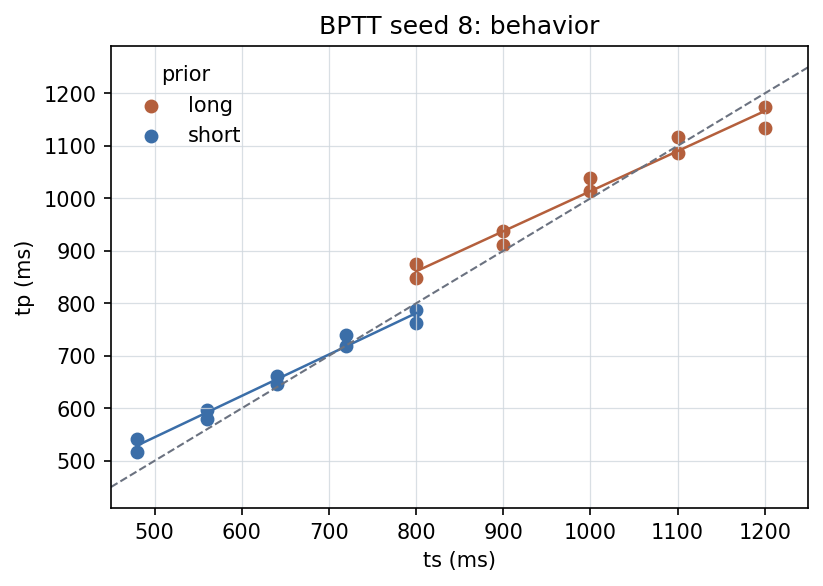

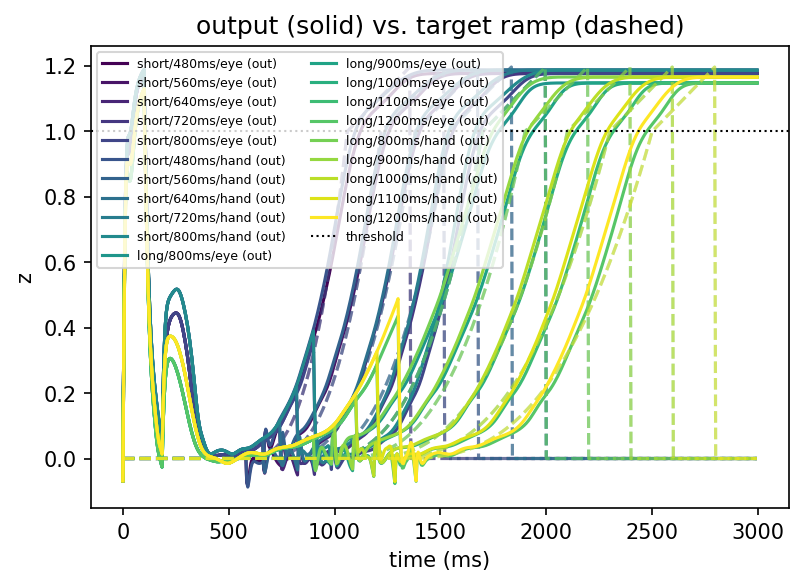

In [3]:
display(Image(filename=REPO_ROOT / "results/figures/bptt/seed_0008/bptt_seed0008_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/bptt/seed_0008/bptt_output_vs_target.png"))

### PC steps=20, seed 1 — flat collapse (0/20 valid, typical of all 10 seeds at this setting)

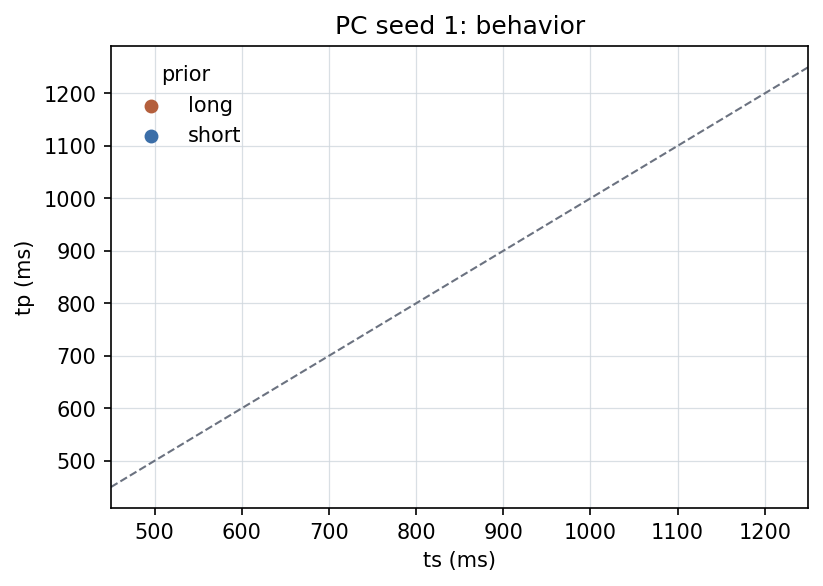

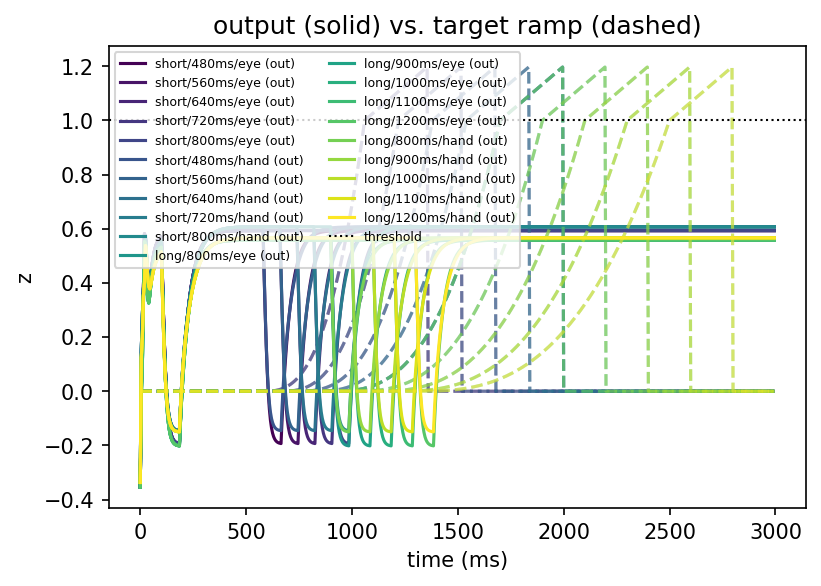

In [4]:
display(Image(filename=REPO_ROOT / "results/figures/pc_steps20/seed_0001/pc_seed0001_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/pc_steps20/seed_0001/pc_output_vs_target.png"))

### PC steps=100, seed 3 — 20/20 valid crossings, but non-Bayesian (near-zero/negative) slope

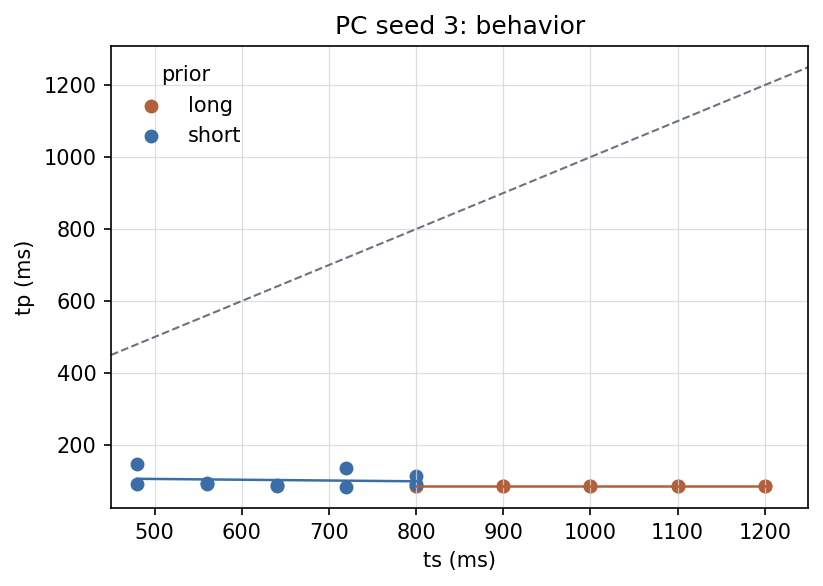

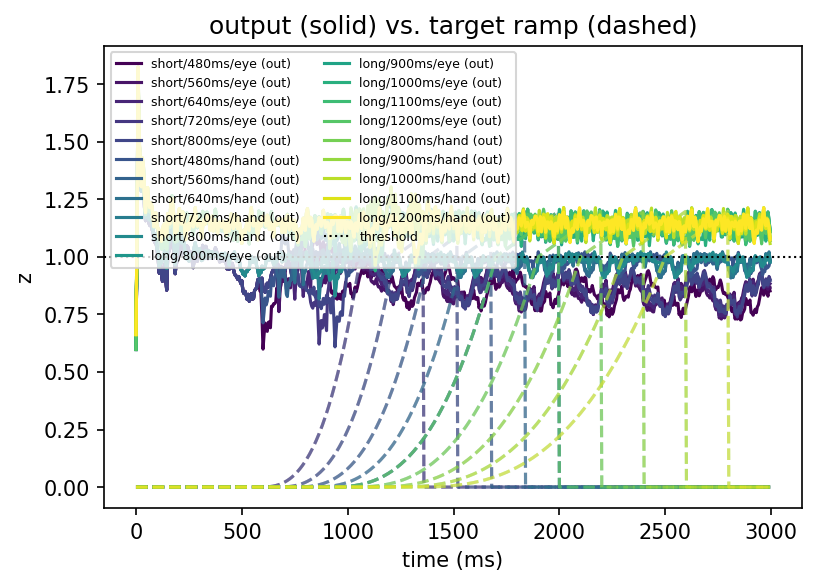

In [5]:
display(Image(filename=REPO_ROOT / "results/figures/pc_steps100/seed_0003/pc_seed0003_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/pc_steps100/seed_0003/pc_output_vs_target.png"))

## BPTT vs PC: RSA / iDSA (model-to-model, no DMFC)

Rule-vs-rule only — DMFC comparison is still blocked (no neural data ingested; see below). Seed
coverage is limited to seeds where *both* rules have surviving activations: 4 shared seeds for
`pc_steps20` (1, 5, 7, 9 — the other 6 lost activations to the collision described above), 9 for
`pc_steps100` (0, 2–9; seed 1 excluded, incomplete run). Computed via `scripts/run_rsa.py` /
`scripts/run_idsa.py --backend builtin` (the `dsa-metric` package isn't installed in this env, so iDSA
falls back to the built-in numpy estimator — same math, no official-package dependency).

RSA distance and iDSA distance are different metrics on different scales — don't compare their
absolute magnitudes to each other, only within each metric. Both are raw distances (no DMFC noise
ceiling to normalize against yet), so treat these as a first look at the seed spread, not calibrated
numbers.

In [6]:
import json

rsa_20 = json.loads((REPO_ROOT / "results/rsa/bptt_vs_pc_steps20/rsa_distances.json").read_text())
rsa_100 = json.loads((REPO_ROOT / "results/rsa/bptt_vs_pc_steps100/rsa_distances.json").read_text())
idsa_20 = json.loads((REPO_ROOT / "results/idsa/bptt_vs_pc_steps20/idsa_distances.json").read_text())
idsa_100 = json.loads((REPO_ROOT / "results/idsa/bptt_vs_pc_steps100/idsa_distances.json").read_text())

rsa_rows = []
for variant, seeds, payload in [("pc_steps20", [1, 5, 7, 9], rsa_20), ("pc_steps100", [0, 2, 3, 4, 5, 6, 7, 8, 9], rsa_100)]:
    for seed, dist in zip(seeds, payload["distances"]["RSA"]["bptt_vs_pc"]):
        rsa_rows.append({"variant": variant, "seed": seed, "rsa_distance": dist})
rsa_df = pd.DataFrame(rsa_rows)
display(Markdown("**RSA distance (BPTT vs PC), per seed**"))
display(rsa_df)
display(rsa_df.groupby("variant")["rsa_distance"].agg(["mean", "std"]).round(4))

**RSA distance (BPTT vs PC), per seed**

,variant,seed,rsa_distance
0,pc_steps20,1,0.684707
1,pc_steps20,5,0.625804
2,pc_steps20,7,0.630743
3,pc_steps20,9,0.513481
4,pc_steps100,0,0.689334
5,pc_steps100,2,0.712878
6,pc_steps100,3,0.386065
7,pc_steps100,4,0.193723
8,pc_steps100,5,0.776633
9,pc_steps100,6,0.233929


,mean,std
variant,,
pc_steps100,0.5736,0.2390
pc_steps20,0.6137,0.0719


In [7]:
idsa_rows = []
for variant, payload in [("pc_steps20", idsa_20), ("pc_steps100", idsa_100)]:
    for seed_str, d in payload["per_seed"].items():
        idsa_rows.append({"variant": variant, "seed": int(seed_str), **d})
idsa_df = pd.DataFrame(idsa_rows)
display(Markdown("**iDSA distance (BPTT vs PC), per seed** (`distance` = combined; `state_distance` /"
                  " `input_distance` = its recurrent- vs input-structure components)"))
display(idsa_df)
display(idsa_df.groupby("variant")[["distance", "state_distance", "input_distance"]].agg(["mean", "std"]).round(2))

**iDSA distance (BPTT vs PC), per seed** (`distance` = combined; `state_distance` / `input_distance` = its recurrent- vs input-structure components)

,variant,seed,distance,input_distance,state_distance
0,pc_steps20,1,224.937179,27.277504,23.870849
1,pc_steps20,5,1769.567209,51.233346,88.813414
2,pc_steps20,7,3022.714093,26.309765,94.069034
3,pc_steps20,9,1465.091042,28.829779,48.819810
4,pc_steps100,0,710.834213,13.487125,16.342610
5,pc_steps100,2,435.601029,34.181569,19.028622
6,pc_steps100,3,151.711259,37.714216,5.279544
7,pc_steps100,4,5136.270070,31.380049,232.089672
8,pc_steps100,5,2574.944590,51.149095,58.713508
9,pc_steps100,6,724.285365,59.306430,145.864498


distance          state_distance        input_distance       
                mean      std           mean    std           mean    std
variant                                                                  
pc_steps100  2075.63  2148.50          92.40  82.59          35.25  13.44
pc_steps20   1620.58  1148.94          63.89  33.47          33.41  11.93

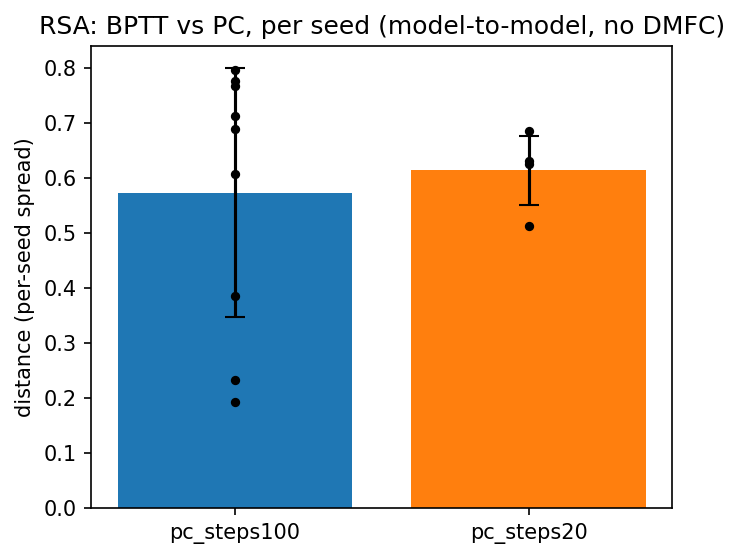

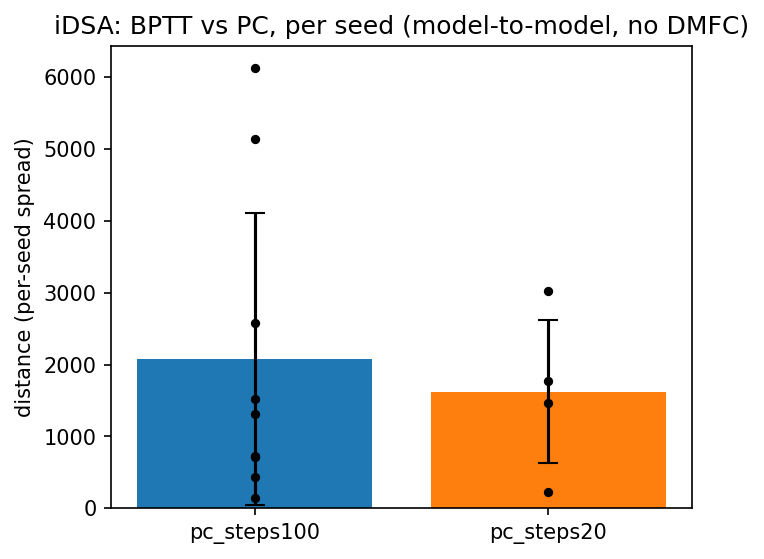

In [8]:
display(Image(filename=REPO_ROOT / "results/rsa/summary_pc_steps_comparison.png"))
display(Image(filename=REPO_ROOT / "results/idsa/summary_pc_steps_comparison.png"))

## Not included in this notebook

- **RSA / iDSA distance to DMFC.** Blocked, not just skipped: no DMFC neural data has been ingested yet
  (`data/` has no raw or processed neural tensors — `src/data/build_neural.py` exists but hasn't been
  run against DANDI 000130). `scripts/run_rsa.py` / `scripts/run_idsa.py` both exist and are ready for
  this once neural ingestion lands — the model-to-model numbers above use the exact same entry points
  in their DMFC-free mode.